# Embedded Interpolants

Each experiment: **FIT** (learn velocity chain) then **GENERATE** (fresh samples).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
sys.path.insert(0, '..')
from src import EmbeddedInterpolants, sliced_wasserstein1, distributions

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 130

def sw1(X, Y):
    X = X.reshape(-1, X.shape[-1]) if X.ndim > 1 else X.reshape(-1,1)
    Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 1 else Y.reshape(-1,1)
    return sliced_wasserstein1(X, Y)

---
## 1. R¹: Gaussian → Bimodal

In [6]:
N_train, N_data, N_new = 600, 300, 800
X1 = distributions.two_modes_1d(N_data, mu=2.5, sigma=0.5).reshape(-1,1)
x_true = distributions.two_modes_1d(N_new, mu=2.5, sigma=0.5).reshape(-1,1)

model_1d = EmbeddedInterpolants(sigma_k=1.5, gamma=0.01, K_steps=80, N_src_max=250)
print('FIT:'); model_1d.fit(np.random.randn(N_train,1), X1, n_iterations=6)
print('\nTRANSPORT:'); res_1d = model_1d.transport(np.random.randn(N_new,1), verbose=True)

sw_t1 = [sw1(s, x_true) for s in model_1d._fit_result['snapshots']]
sw_n1 = [sw1(s, x_true) for s in res_1d['snapshots']]
print(f'\nTrain SW1={sw_t1[-1]:.3f}, New SW1={sw_n1[-1]:.3f}')

FIT:
  Iter 1: std=2.047,  lift_ratio=0.649,  N=550
  Iter 2: std=2.414,  lift_ratio=0.758,  N=550
  Iter 3: std=2.501,  lift_ratio=0.528,  N=550
  Iter 4: std=2.539,  lift_ratio=0.470,  N=550
  Iter 5: std=2.502,  lift_ratio=0.272,  N=550
  Iter 6: std=2.490,  lift_ratio=0.170,  N=550

TRANSPORT:
  Iter 1: std=2.062,  lift_ratio=0.643
  Iter 2: std=2.426,  lift_ratio=0.744
  Iter 3: std=2.514,  lift_ratio=0.501
  Iter 4: std=2.553,  lift_ratio=0.442
  Iter 5: std=2.514,  lift_ratio=0.280
  Iter 6: std=2.498,  lift_ratio=0.175

Train SW1=0.147, New SW1=0.170


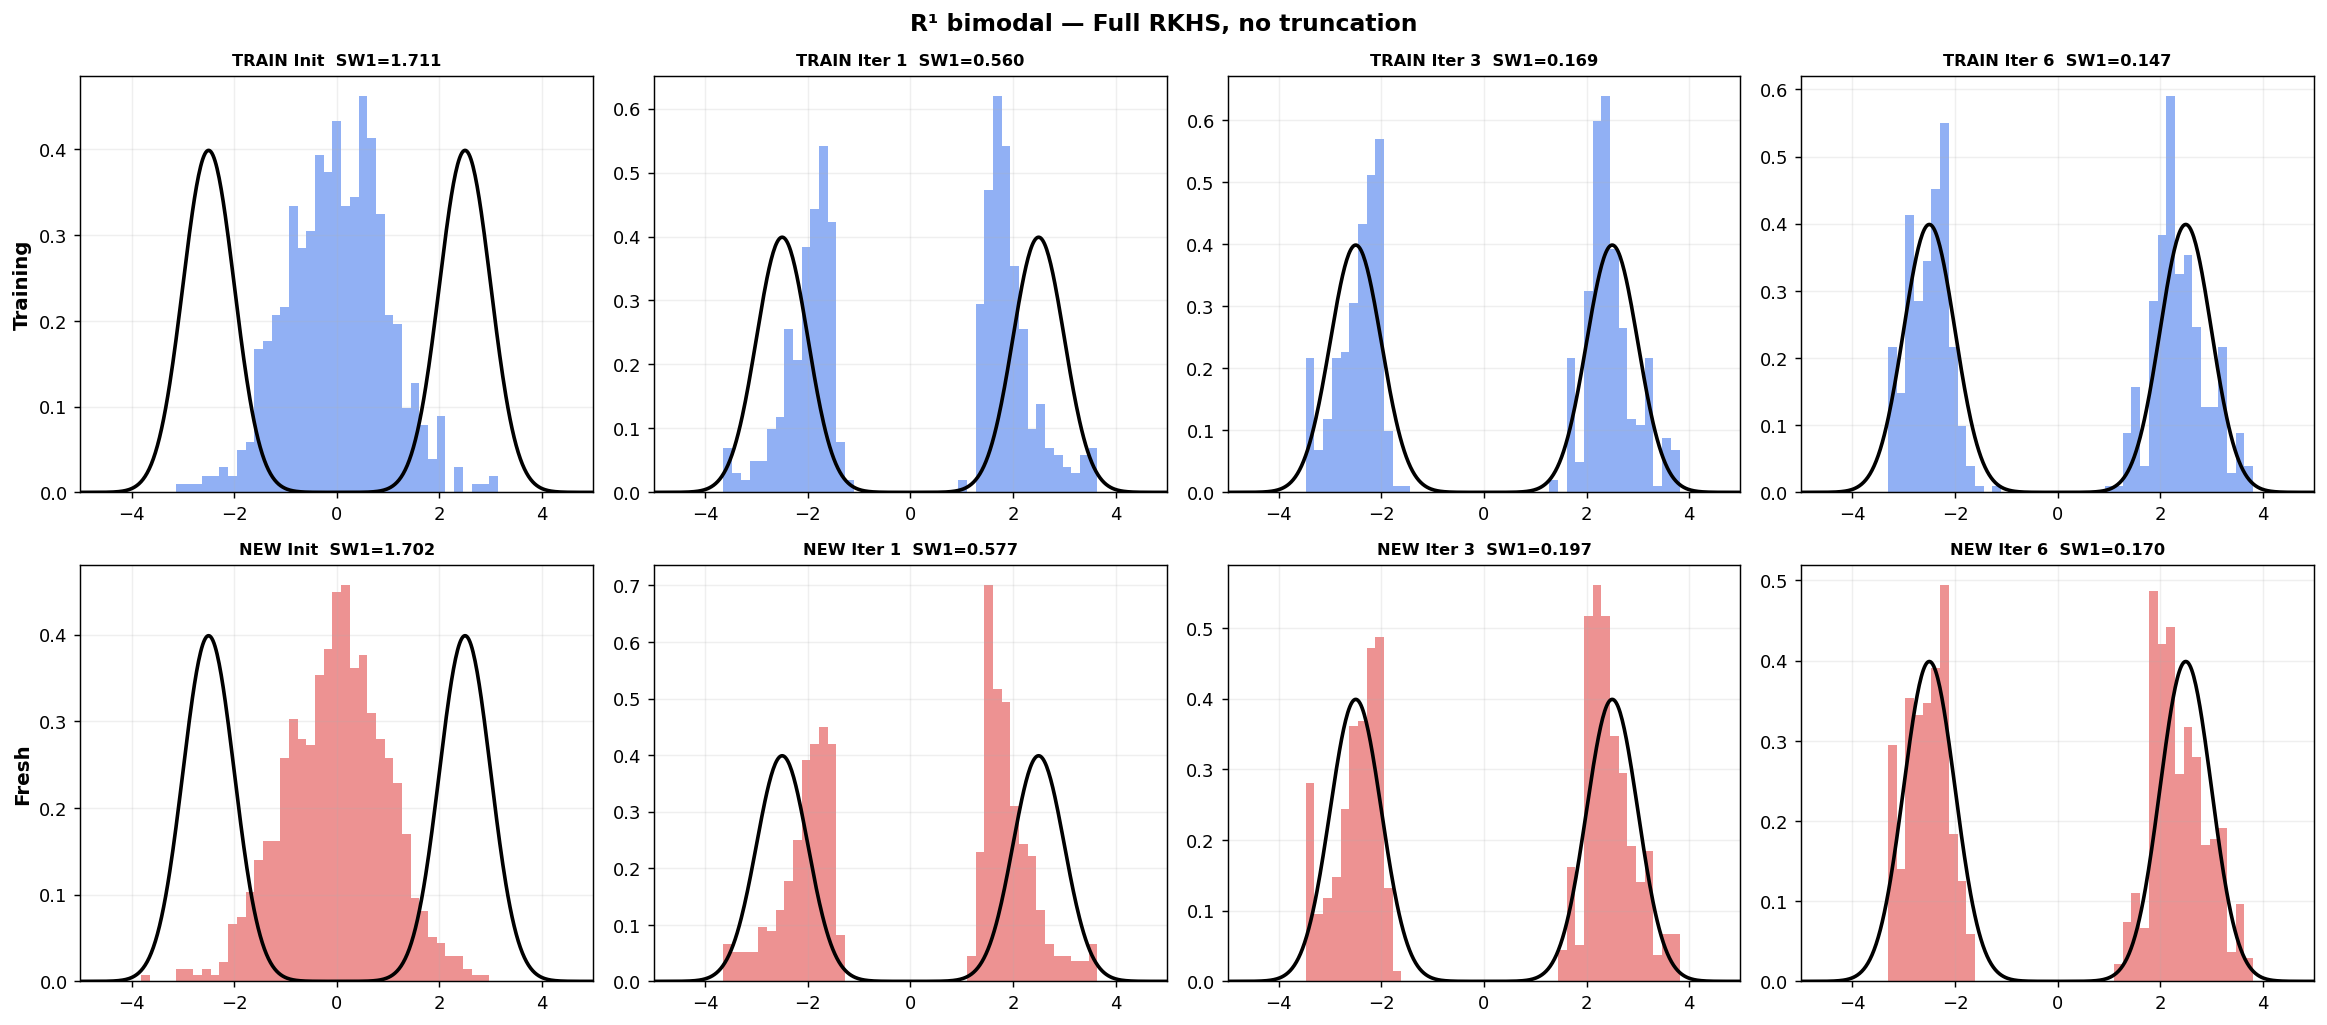

In [7]:
xd = np.linspace(-5,5,500)
rho = 0.5/(0.5*np.sqrt(2*np.pi))*(np.exp(-(xd-2.5)**2/0.5)+np.exp(-(xd+2.5)**2/0.5))
bins = np.linspace(-5,5,60)
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for col, it in enumerate([0,1,3,6]):
    ax = axes[0,col]
    ax.hist(model_1d._fit_result['snapshots'][it][:,0], bins=bins, density=True, alpha=0.5, color='#2563eb')
    ax.plot(xd,rho,'k-',lw=2); lab='Init' if it==0 else f'Iter {it}'
    ax.set_title(f'TRAIN {lab}  SW1={sw_t1[it]:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlim(-5,5); ax.grid(True,alpha=0.2)
    if col==0: ax.set_ylabel('Training', fontsize=11, fontweight='bold')
    ax = axes[1,col]
    ax.hist(res_1d['snapshots'][it][:,0], bins=bins, density=True, alpha=0.5, color='#dc2626')
    ax.plot(xd,rho,'k-',lw=2)
    ax.set_title(f'NEW {lab}  SW1={sw_n1[it]:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlim(-5,5); ax.grid(True,alpha=0.2)
    if col==0: ax.set_ylabel('Fresh', fontsize=11, fontweight='bold')
fig.suptitle('R¹ bimodal — Full RKHS, no truncation', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 2. R² — 3 Modes (Triangle)

In [8]:
N_train, N_data, N_new = 500, 250, 600
X1_2d = distributions.three_modes_2d(N_data)
x_true_2d = distributions.three_modes_2d(N_new)

model_2d = EmbeddedInterpolants(sigma_k=1.5, gamma=0.01, K_steps=50, N_src_max=200)
print('FIT:'); model_2d.fit(np.random.randn(N_train,2), X1_2d, n_iterations=6)
print('\nTRANSPORT:'); res_2d = model_2d.transport(np.random.randn(N_new,2), verbose=True)

sw_t2 = [sw1(s, x_true_2d) for s in model_2d._fit_result['snapshots']]
sw_n2 = [sw1(s, x_true_2d) for s in res_2d['snapshots']]
print(f'\nTrain SW1={sw_t2[-1]:.3f}, New SW1={sw_n2[-1]:.3f}')

FIT:
  Iter 1: std=1.594,  lift_ratio=0.577,  N=450
  Iter 2: std=1.787,  lift_ratio=0.680,  N=450
  Iter 3: std=1.836,  lift_ratio=0.403,  N=450
  Iter 4: std=1.825,  lift_ratio=0.518,  N=450
  Iter 5: std=1.828,  lift_ratio=0.500,  N=450
  Iter 6: std=1.814,  lift_ratio=0.296,  N=450

TRANSPORT:
  Iter 1: std=1.588,  lift_ratio=0.579
  Iter 2: std=1.784,  lift_ratio=0.678
  Iter 3: std=1.837,  lift_ratio=0.394
  Iter 4: std=1.826,  lift_ratio=0.529
  Iter 5: std=1.829,  lift_ratio=0.505
  Iter 6: std=1.816,  lift_ratio=0.289

Train SW1=0.088, New SW1=0.093


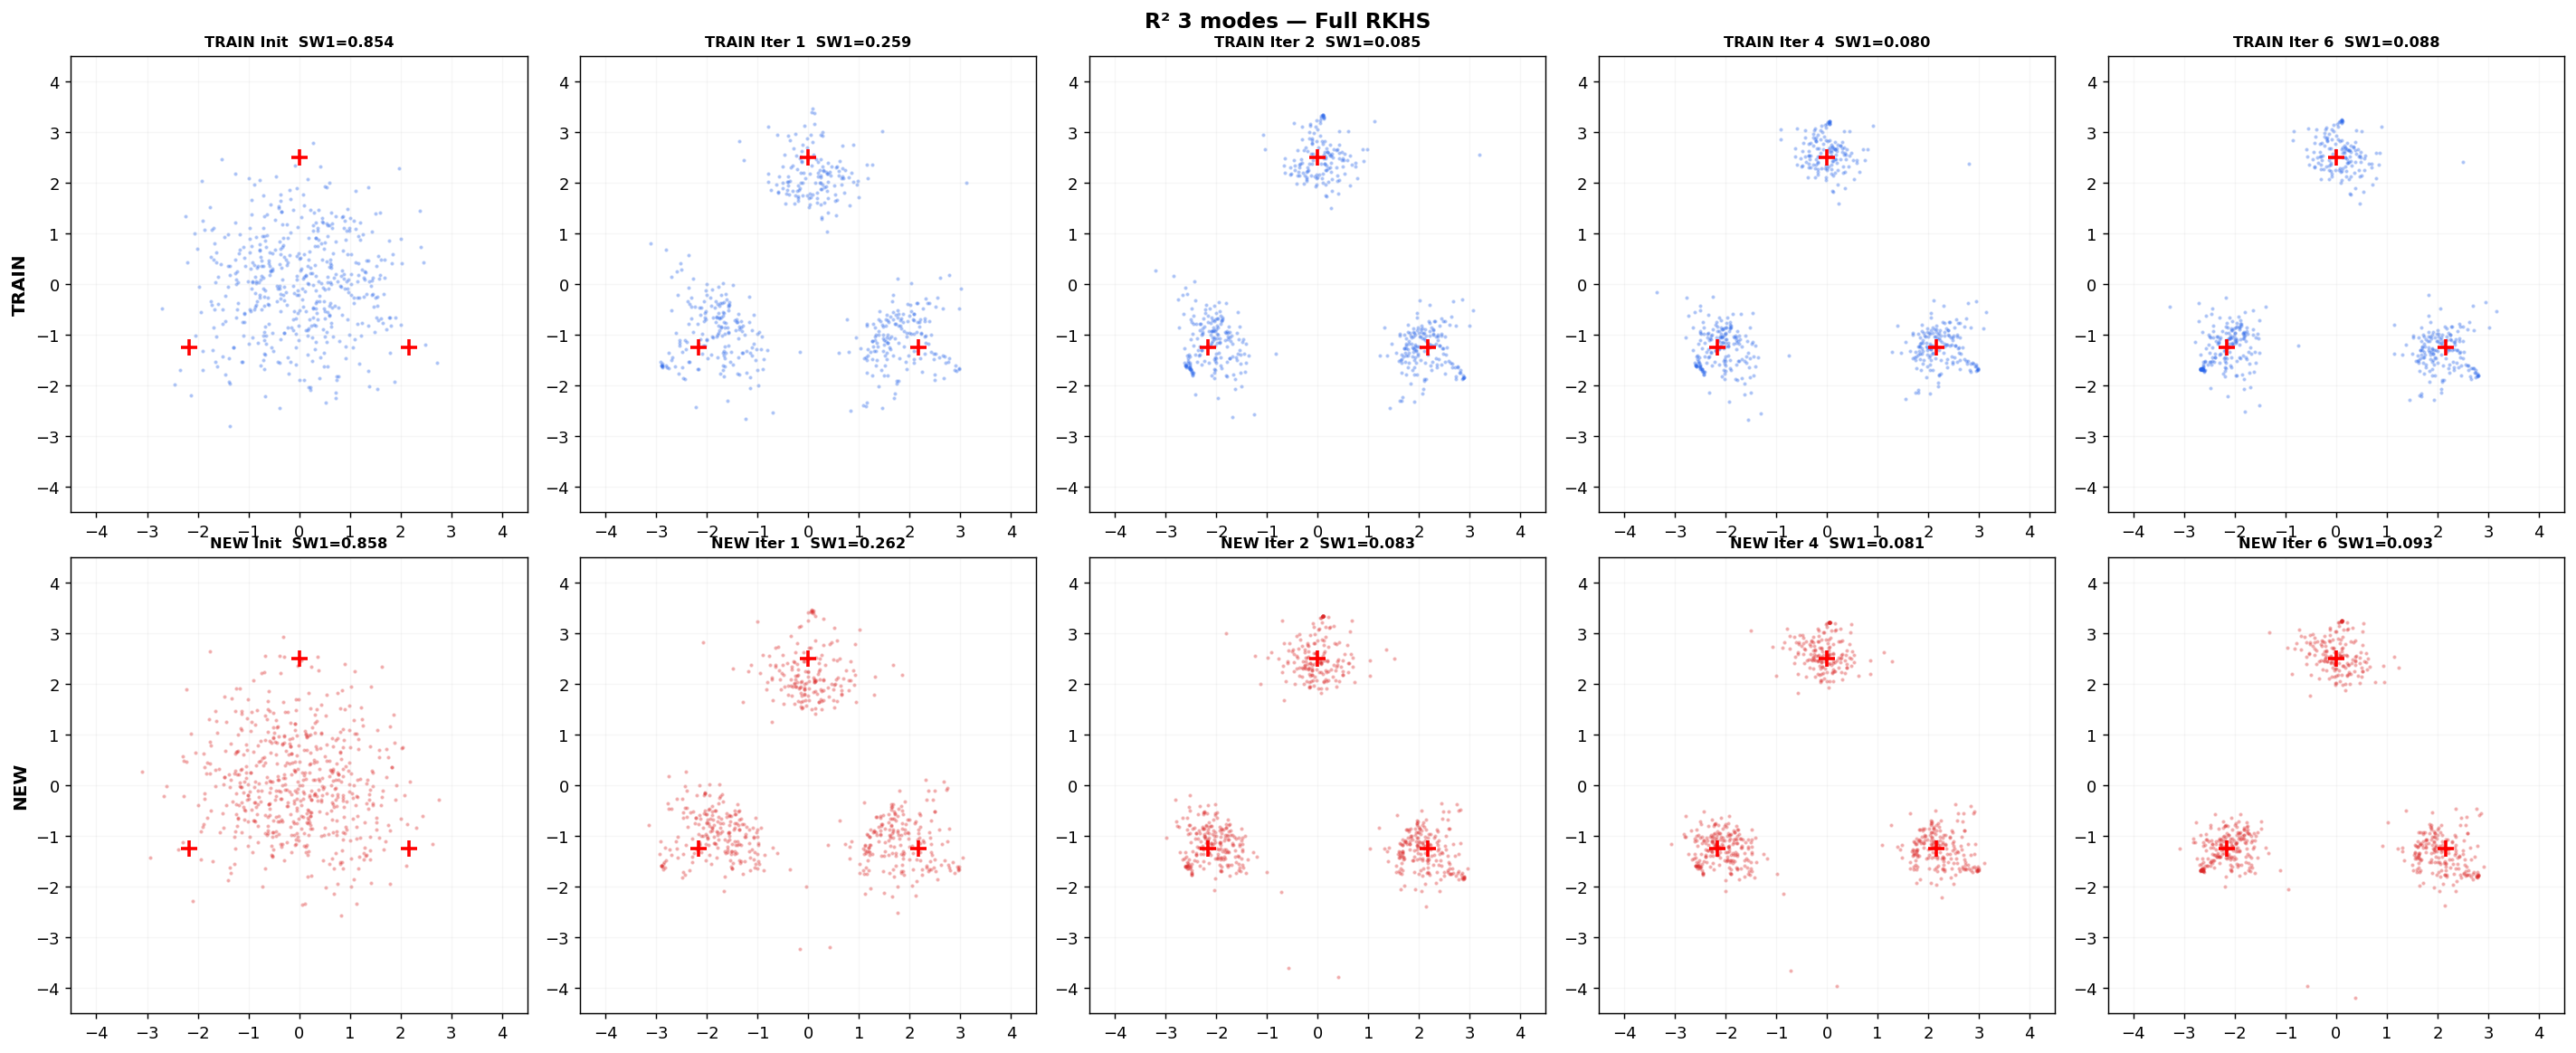

In [9]:
angles_3 = np.array([np.pi/2, np.pi/2+2*np.pi/3, np.pi/2+4*np.pi/3])
centers_3 = 2.5*np.column_stack([np.cos(angles_3), np.sin(angles_3)])
fig, axes = plt.subplots(2, 5, figsize=(22,9))
for col, it in enumerate([0,1,2,4,6]):
    for row, (sn,c,sv,lb) in enumerate([
        (model_2d._fit_result['snapshots'],'#2563eb',sw_t2,'TRAIN'),
        (res_2d['snapshots'],'#dc2626',sw_n2,'NEW')]):
        ax = axes[row,col]; ax.scatter(sn[it][:,0],sn[it][:,1],s=2,alpha=0.25,c=c)
        for cc in centers_3: ax.plot(cc[0],cc[1],'r+',ms=10,mew=2)
        itl = 'Init' if it==0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlim(-4.5,4.5); ax.set_ylim(-4.5,4.5); ax.set_aspect('equal'); ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb, fontsize=11, fontweight='bold')
fig.suptitle('R² 3 modes — Full RKHS', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 3. R³ — 4 Modes (Tetrahedron)

In [10]:
N_train, N_data, N_new = 500, 250, 600
X1_3d = distributions.four_modes_3d(N_data)
x_true_3d = distributions.four_modes_3d(N_new)
model_3d = EmbeddedInterpolants(sigma_k=1.8, gamma=0.01, K_steps=50, N_src_max=200)
print('FIT:'); model_3d.fit(np.random.randn(N_train,3), X1_3d, n_iterations=6)
print('\nTRANSPORT:'); res_3d = model_3d.transport(np.random.randn(N_new,3), verbose=True)
sw_t3 = [sw1(s, x_true_3d) for s in model_3d._fit_result['snapshots']]
sw_n3 = [sw1(s, x_true_3d) for s in res_3d['snapshots']]
print(f'\nTrain SW1={sw_t3[-1]:.3f}, New SW1={sw_n3[-1]:.3f}')

FIT:
  Iter 1: std=1.373,  lift_ratio=0.529,  N=450
  Iter 2: std=1.483,  lift_ratio=0.561,  N=450
  Iter 3: std=1.497,  lift_ratio=0.552,  N=450
  Iter 4: std=1.497,  lift_ratio=0.509,  N=450
  Iter 5: std=1.475,  lift_ratio=0.575,  N=450
  Iter 6: std=1.496,  lift_ratio=0.157,  N=450

TRANSPORT:
  Iter 1: std=1.417,  lift_ratio=0.532
  Iter 2: std=1.524,  lift_ratio=0.550
  Iter 3: std=1.537,  lift_ratio=0.524
  Iter 4: std=1.541,  lift_ratio=0.486
  Iter 5: std=1.518,  lift_ratio=0.567
  Iter 6: std=1.540,  lift_ratio=0.153

Train SW1=0.130, New SW1=0.190


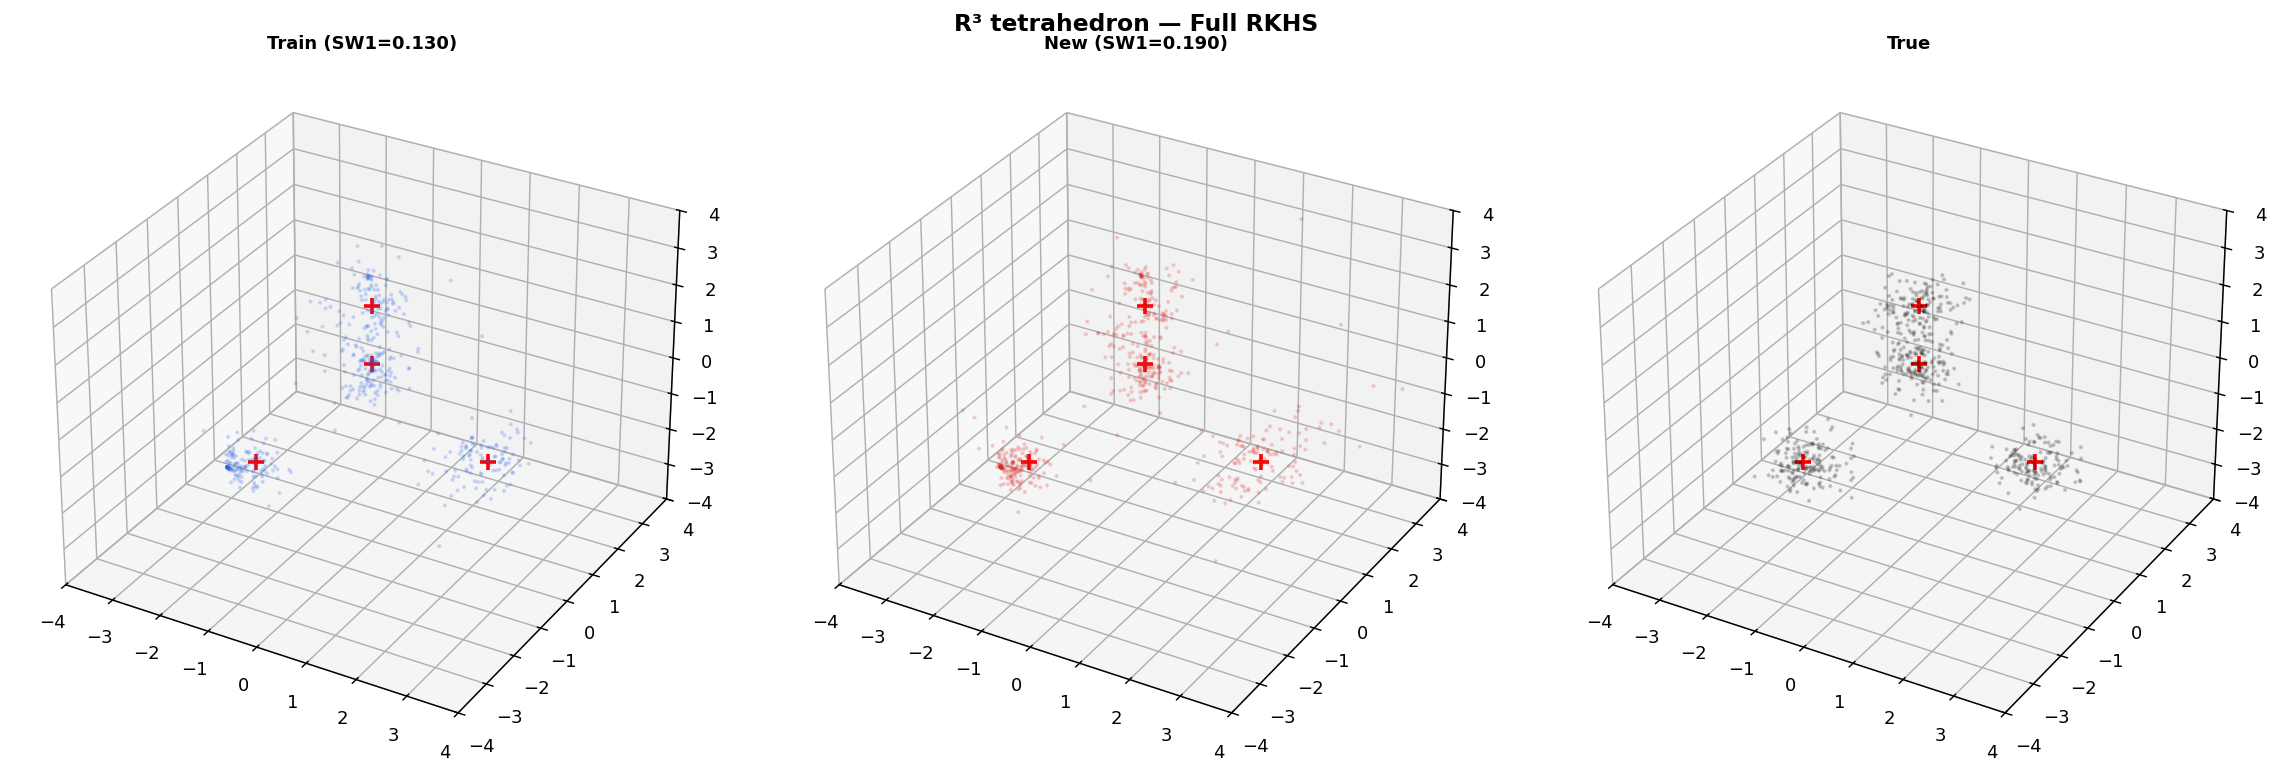

In [11]:
r3=2.5; tc=np.array([[0,0,r3],[r3*np.sqrt(8/9),0,-r3/3],[-r3*np.sqrt(2/9),r3*np.sqrt(2/3),-r3/3],[-r3*np.sqrt(2/9),-r3*np.sqrt(2/3),-r3/3]])
fig = plt.figure(figsize=(18,6))
for i,(data,title,color) in enumerate([
    (model_3d._fit_result['particles'],f'Train (SW1={sw_t3[-1]:.3f})','#2563eb'),
    (res_3d['particles'],f'New (SW1={sw_n3[-1]:.3f})','#dc2626'),
    (x_true_3d,'True','black')]):
    ax=fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(data[:,0],data[:,1],data[:,2],s=2,alpha=0.15,c=color)
    for m in tc: ax.scatter(*m,s=80,c='red',marker='+',linewidths=2)
    ax.set_xlim(-4,4);ax.set_ylim(-4,4);ax.set_zlim(-4,4);ax.set_title(title,fontweight='bold',fontsize=10)
fig.suptitle('R³ tetrahedron — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()

---
## 4. R² — Checkerboard 3×3

In [13]:
csz,off=2.0,-3.0
cells=[(off+j*csz,off+i*csz) for i in range(3) for j in range(3) if (i+j)%2==0]
def sample_board(n):
    K=len(cells);s=np.zeros((n,2));lab=np.random.randint(0,K,n)
    for idx,(xl,yl) in enumerate(cells):
        m=lab==idx;s[m,0]=np.random.uniform(xl,xl+csz,m.sum());s[m,1]=np.random.uniform(yl,yl+csz,m.sum())
    return s
def draw_board(ax):
    for xl,yl in cells: ax.add_patch(Rectangle((xl,yl),csz,csz,fill=True,fc='green',alpha=0.1,ec='green',lw=1))
def pct_in(pts):
    ins=np.zeros(len(pts),dtype=bool)
    for xl,yl in cells: ins|=(pts[:,0]>=xl)&(pts[:,0]<=xl+csz)&(pts[:,1]>=yl)&(pts[:,1]<=yl+csz)
    return ins.mean()*100

N_train,N_data,N_new=600,400,800
X1_b=sample_board(N_data); x_true_b=sample_board(N_new)
model_b=EmbeddedInterpolants(sigma_k=1.2,gamma=0.01,K_steps=60,N_src_max=250)
print('FIT:'); model_b.fit(np.random.randn(N_train,2), X1_b, n_iterations=8)
print('\nTRANSPORT:'); res_b=model_b.transport(np.random.randn(N_new,2), verbose=True)

FIT:
  Iter 1: std=1.364,  lift_ratio=0.339,  N=650
  Iter 2: std=1.587,  lift_ratio=0.388,  N=650
  Iter 3: std=1.715,  lift_ratio=0.380,  N=650
  Iter 4: std=1.795,  lift_ratio=0.358,  N=650
  Iter 5: std=1.805,  lift_ratio=0.259,  N=650
  Iter 6: std=1.829,  lift_ratio=0.405,  N=650
  Iter 7: std=1.838,  lift_ratio=0.383,  N=650
  Iter 8: std=1.840,  lift_ratio=0.431,  N=650

TRANSPORT:
  Iter 1: std=1.363,  lift_ratio=0.334
  Iter 2: std=1.587,  lift_ratio=0.382
  Iter 3: std=1.718,  lift_ratio=0.365
  Iter 4: std=1.793,  lift_ratio=0.353
  Iter 5: std=1.806,  lift_ratio=0.258
  Iter 6: std=1.829,  lift_ratio=0.399
  Iter 7: std=1.833,  lift_ratio=0.379
  Iter 8: std=1.836,  lift_ratio=0.429


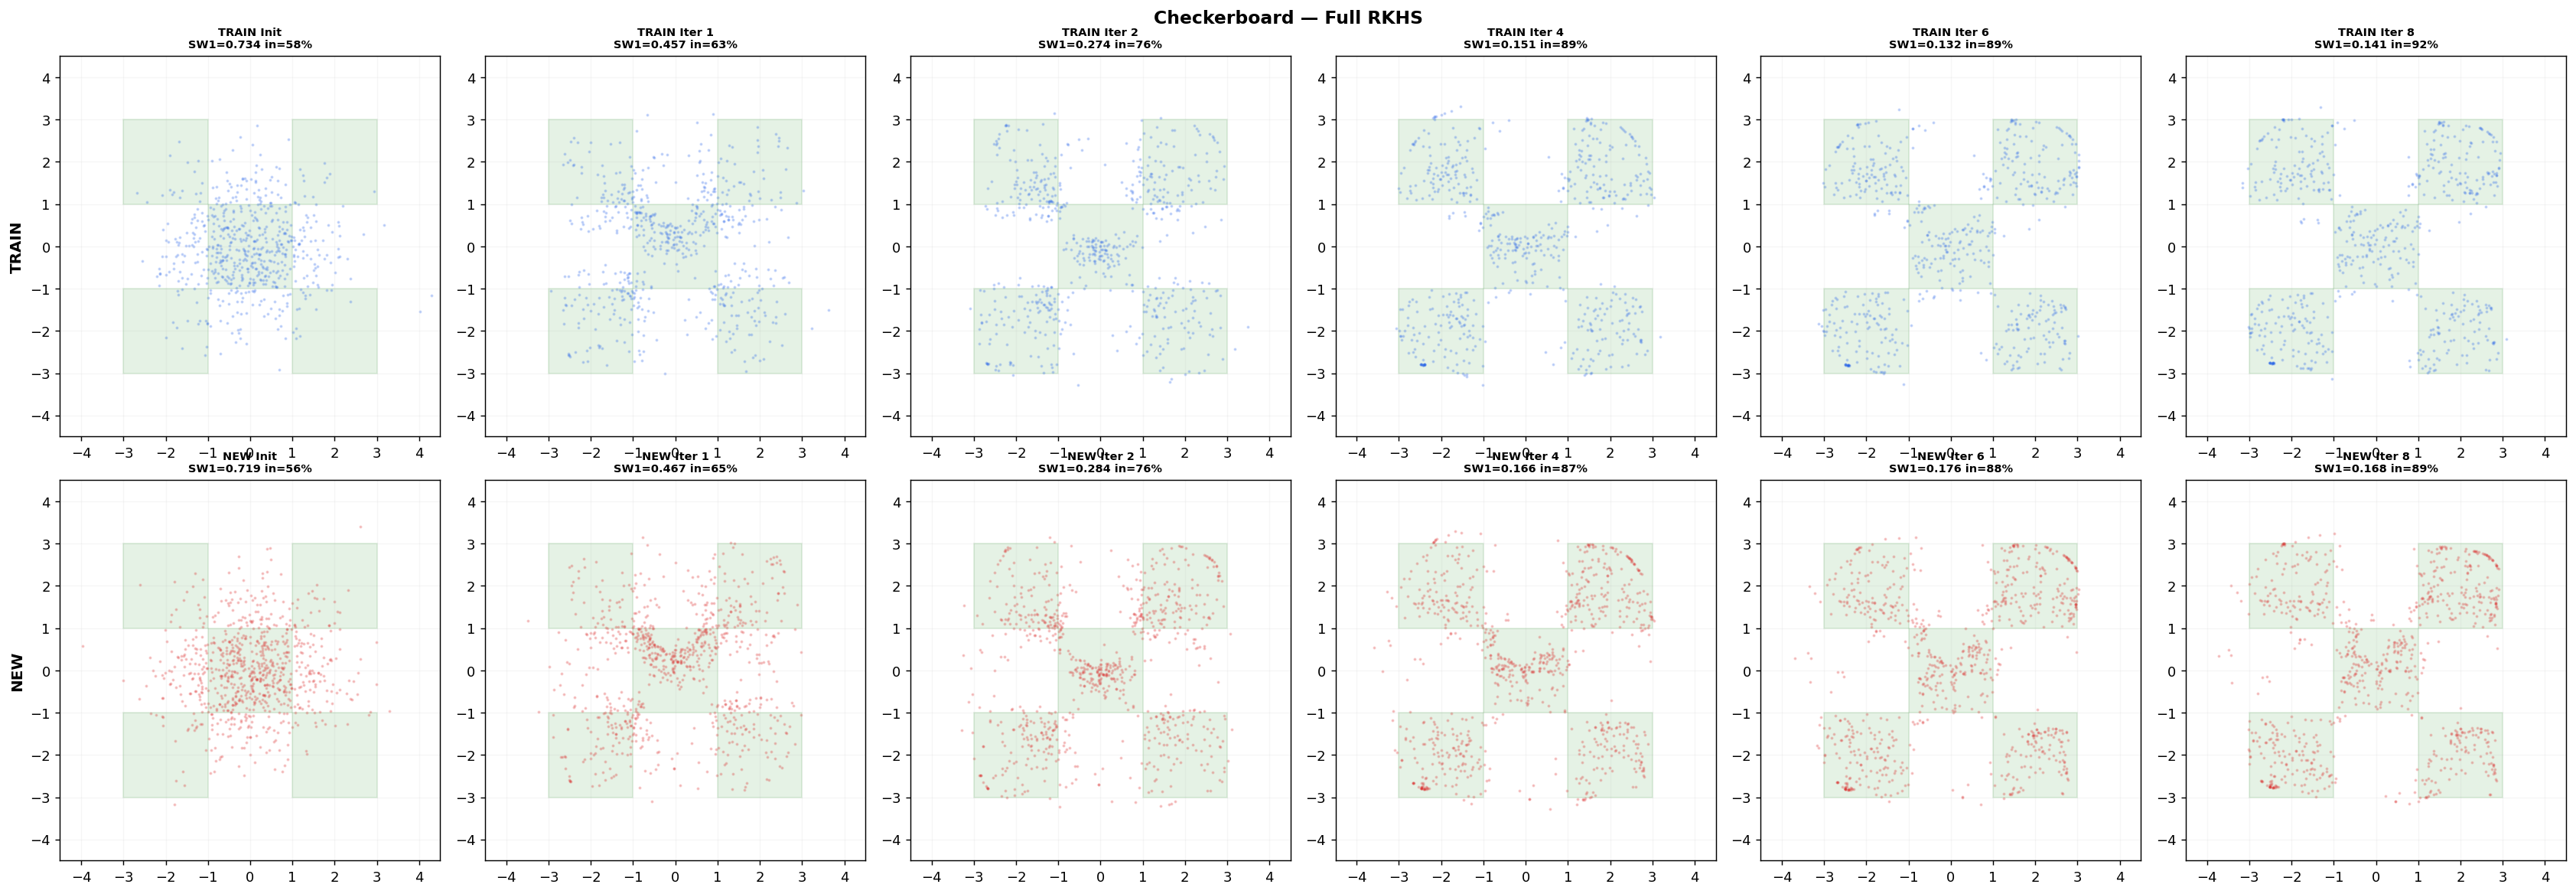

Train: SW1=0.141, in=92%
New:   SW1=0.168, in=89%


In [14]:
sw_tb=[sw1(s,x_true_b) for s in model_b._fit_result['snapshots']]
sw_nb=[sw1(s,x_true_b) for s in res_b['snapshots']]
fig,axes=plt.subplots(2,6,figsize=(26,9))
for col,it in enumerate([0,1,2,4,6,8]):
    for row,(sn,c,sv,lb) in enumerate([
        (model_b._fit_result['snapshots'],'#2563eb',sw_tb,'TRAIN'),
        (res_b['snapshots'],'#dc2626',sw_nb,'NEW')]):
        ax=axes[row,col]; draw_board(ax)
        ax.scatter(sn[it][:,0],sn[it][:,1],s=1.5,alpha=0.2,c=c)
        itl='Init' if it==0 else f'Iter {it}'; pi=pct_in(sn[it])
        ax.set_title(f'{lb} {itl}\nSW1={sv[it]:.3f} in={pi:.0f}%',fontsize=8,fontweight='bold')
        ax.set_xlim(-4.5,4.5);ax.set_ylim(-4.5,4.5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb,fontsize=11,fontweight='bold')
fig.suptitle('Checkerboard — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()
print(f'Train: SW1={sw_tb[-1]:.3f}, in={pct_in(model_b._fit_result["particles"]):.0f}%')
print(f'New:   SW1={sw_nb[-1]:.3f}, in={pct_in(res_b["particles"]):.0f}%')

---
## 5. R² — Ring of 8

In [15]:
N_train,N_data,N_new=500,300,600
X1_r=distributions.ring_2d(N_data,K=8,r=3.0,sigma=0.3)
x_true_r=distributions.ring_2d(N_new,K=8,r=3.0,sigma=0.3)
model_r=EmbeddedInterpolants(sigma_k=1.5,gamma=0.01,K_steps=50,N_src_max=200)
print('FIT:'); model_r.fit(np.random.randn(N_train,2),X1_r,n_iterations=8)
print('\nTRANSPORT:'); res_r=model_r.transport(np.random.randn(N_new,2),verbose=True)

FIT:
  Iter 1: std=1.770,  lift_ratio=0.532,  N=500
  Iter 2: std=2.054,  lift_ratio=0.604,  N=500
  Iter 3: std=2.134,  lift_ratio=0.433,  N=500
  Iter 4: std=2.160,  lift_ratio=0.296,  N=500
  Iter 5: std=2.142,  lift_ratio=0.331,  N=500
  Iter 6: std=2.167,  lift_ratio=0.189,  N=500
  Iter 7: std=2.126,  lift_ratio=0.344,  N=500
  Iter 8: std=2.104,  lift_ratio=0.388,  N=500

TRANSPORT:
  Iter 1: std=1.727,  lift_ratio=0.548
  Iter 2: std=2.023,  lift_ratio=0.624
  Iter 3: std=2.110,  lift_ratio=0.441
  Iter 4: std=2.147,  lift_ratio=0.310
  Iter 5: std=2.129,  lift_ratio=0.351
  Iter 6: std=2.153,  lift_ratio=0.192
  Iter 7: std=2.109,  lift_ratio=0.349
  Iter 8: std=2.091,  lift_ratio=0.387


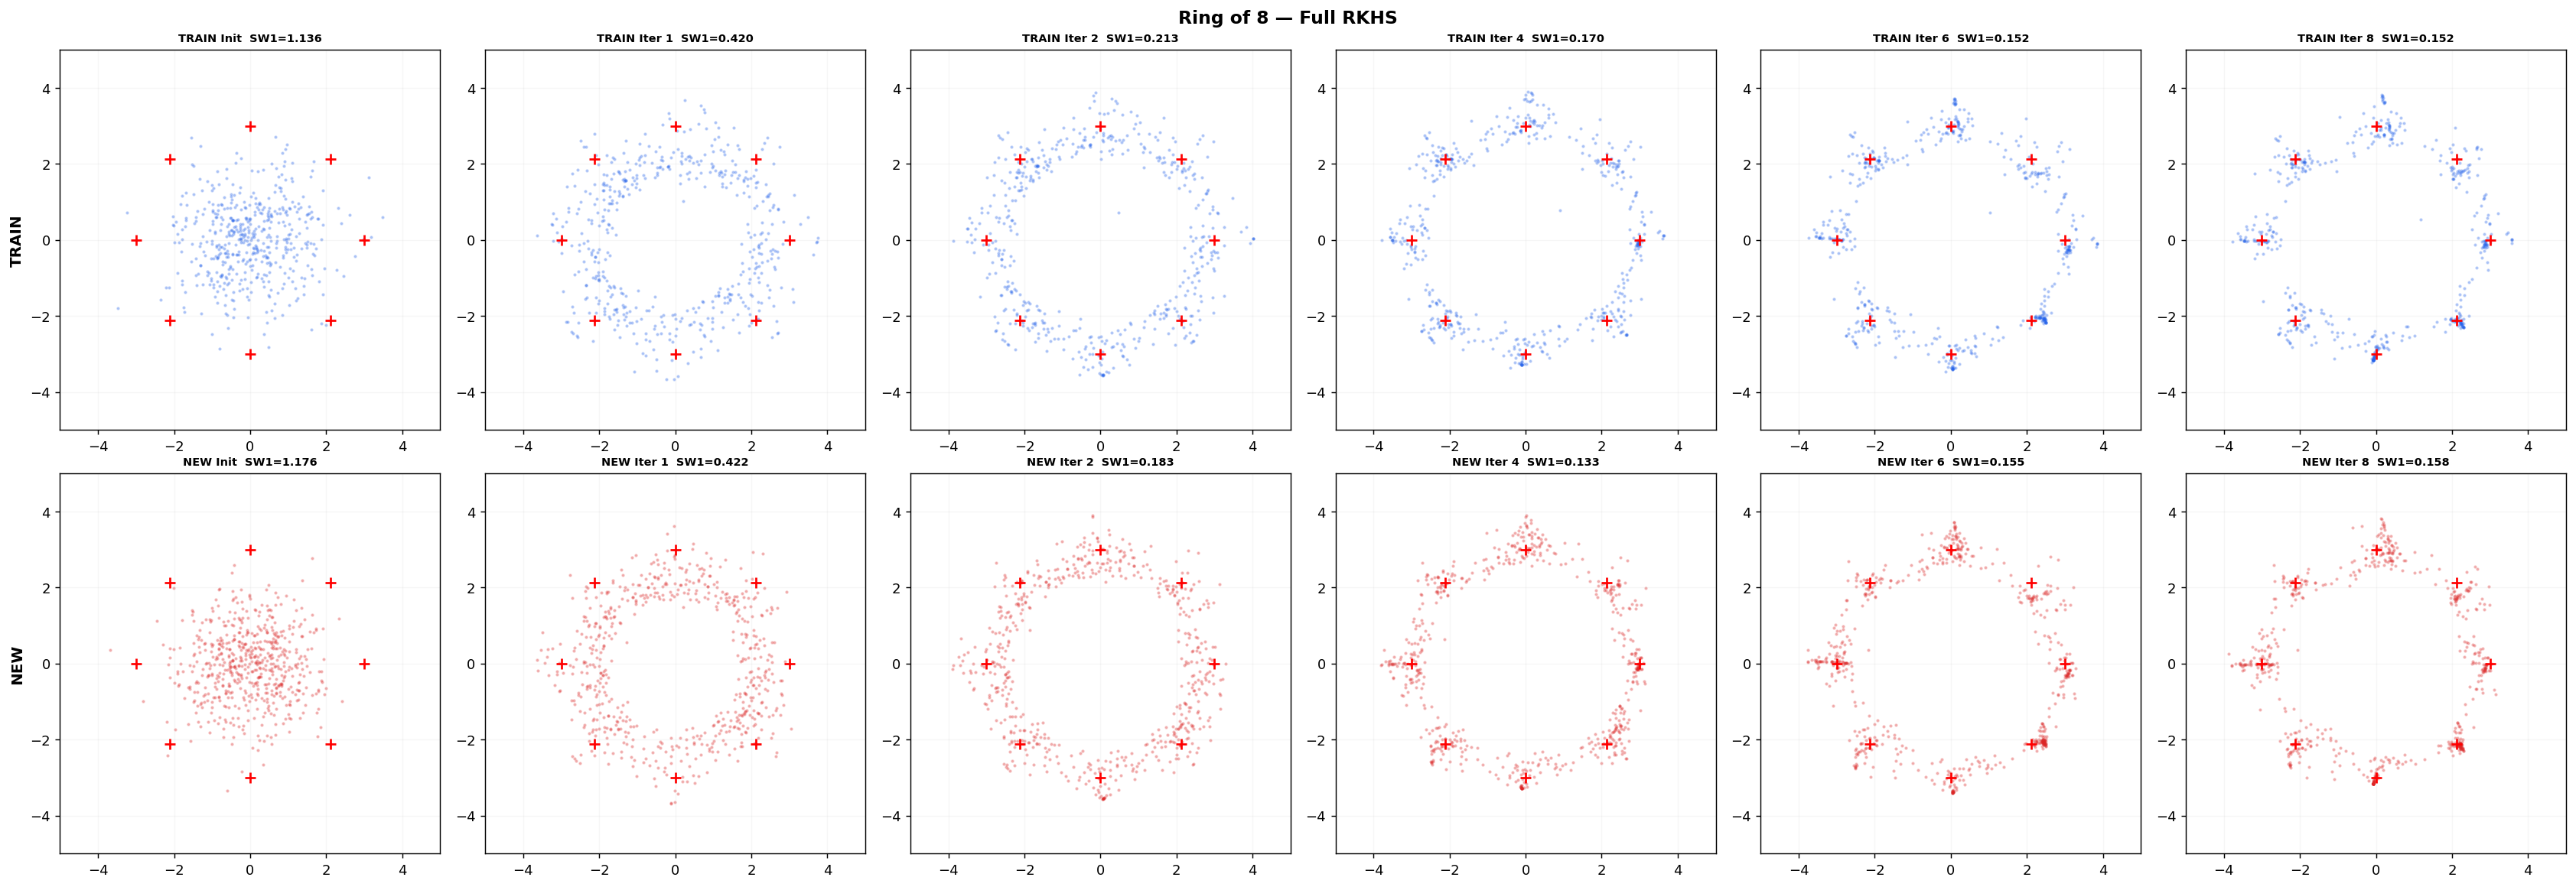

In [16]:
sw_tr=[sw1(s,x_true_r) for s in model_r._fit_result['snapshots']]
sw_nr=[sw1(s,x_true_r) for s in res_r['snapshots']]
rc=3.0*np.column_stack([np.cos(np.linspace(0,2*np.pi,8,endpoint=False)),np.sin(np.linspace(0,2*np.pi,8,endpoint=False))])
fig,axes=plt.subplots(2,6,figsize=(26,9))
for col,it in enumerate([0,1,2,4,6,8]):
    for row,(sn,c,sv,lb) in enumerate([
        (model_r._fit_result['snapshots'],'#2563eb',sw_tr,'TRAIN'),
        (res_r['snapshots'],'#dc2626',sw_nr,'NEW')]):
        ax=axes[row,col]; ax.scatter(sn[it][:,0],sn[it][:,1],s=2,alpha=0.25,c=c)
        for cc in rc: ax.plot(cc[0],cc[1],'r+',ms=8,mew=1.5)
        itl='Init' if it==0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}',fontsize=8,fontweight='bold')
        ax.set_xlim(-5,5);ax.set_ylim(-5,5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb,fontsize=11,fontweight='bold')
fig.suptitle('Ring of 8 — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()

---
## 6. Summary

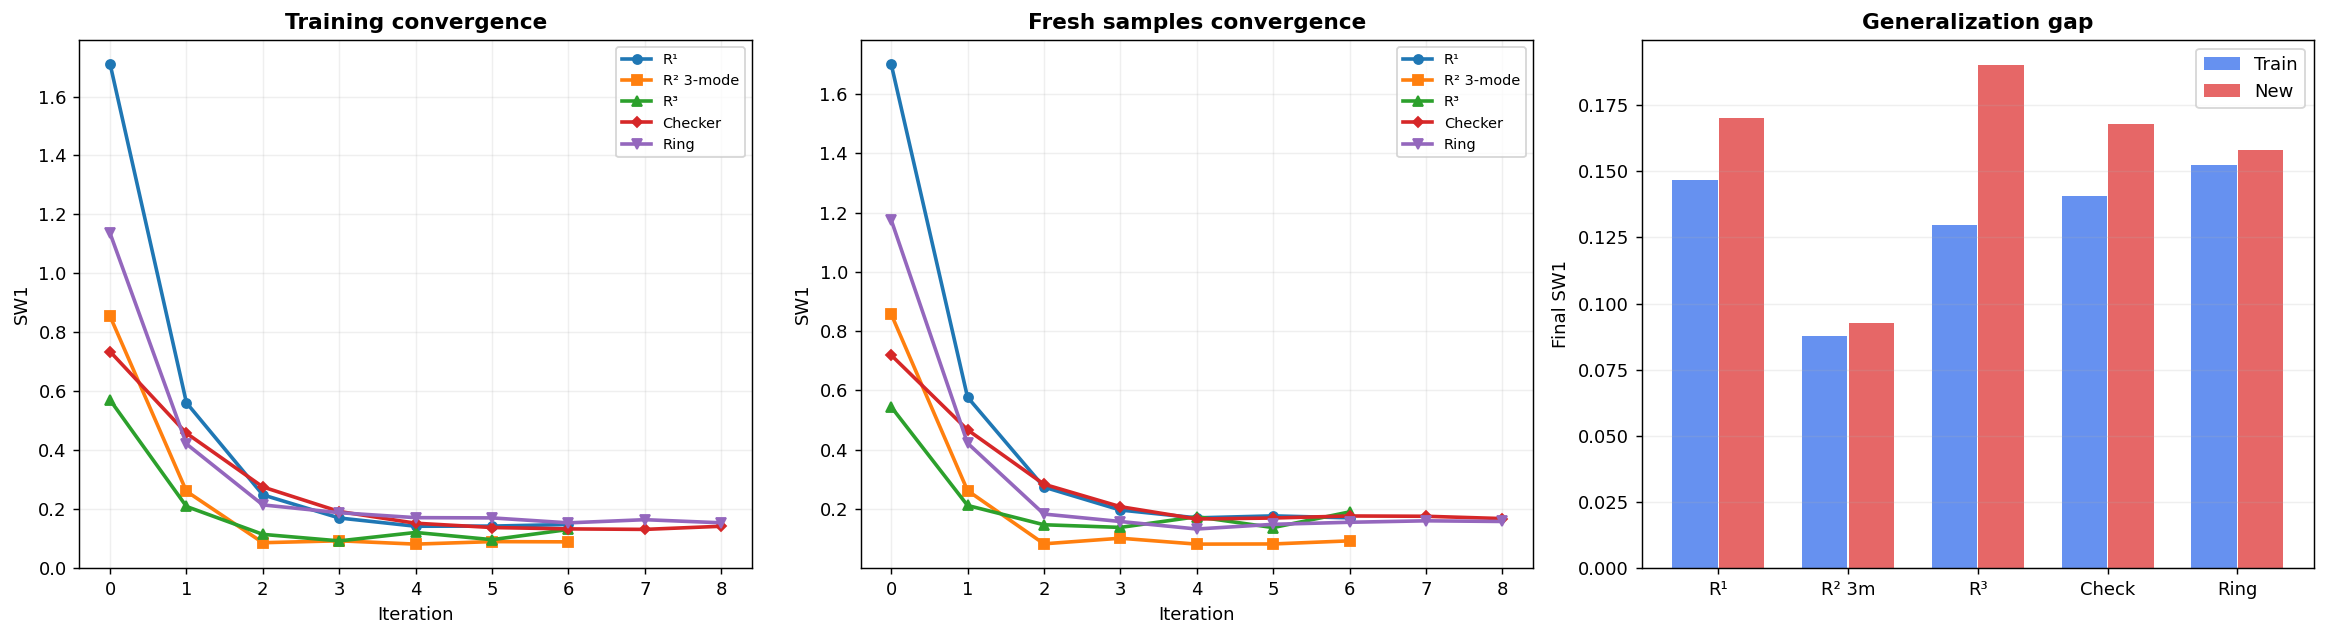

  R¹     train=0.147 new=0.170 gap=+0.024
  R² 3m  train=0.088 new=0.093 gap=+0.005
  R³     train=0.130 new=0.190 gap=+0.060
  Check  train=0.141 new=0.168 gap=+0.027
  Ring   train=0.152 new=0.158 gap=+0.005


In [17]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
ax=axes[0]
ax.plot(sw_t1,'o-',lw=2,ms=5,label='R¹');ax.plot(sw_t2,'s-',lw=2,ms=5,label='R² 3-mode')
ax.plot(sw_t3,'^-',lw=2,ms=5,label='R³');ax.plot(sw_tb,'D-',lw=2,ms=4,label='Checker')
ax.plot(sw_tr,'v-',lw=2,ms=5,label='Ring')
ax.set_xlabel('Iteration');ax.set_ylabel('SW1');ax.set_title('Training convergence',fontweight='bold')
ax.legend(fontsize=8);ax.grid(True,alpha=0.2)
ax=axes[1]
ax.plot(sw_n1,'o-',lw=2,ms=5,label='R¹');ax.plot(sw_n2,'s-',lw=2,ms=5,label='R² 3-mode')
ax.plot(sw_n3,'^-',lw=2,ms=5,label='R³');ax.plot(sw_nb,'D-',lw=2,ms=4,label='Checker')
ax.plot(sw_nr,'v-',lw=2,ms=5,label='Ring')
ax.set_xlabel('Iteration');ax.set_ylabel('SW1');ax.set_title('Fresh samples convergence',fontweight='bold')
ax.legend(fontsize=8);ax.grid(True,alpha=0.2)
ax=axes[2]
names=['R¹','R² 3m','R³','Check','Ring']
tf=[sw_t1[-1],sw_t2[-1],sw_t3[-1],sw_tb[-1],sw_tr[-1]]
nf=[sw_n1[-1],sw_n2[-1],sw_n3[-1],sw_nb[-1],sw_nr[-1]]
x_pos=np.arange(5)
ax.bar(x_pos-0.18,tf,0.35,color='#2563eb',alpha=0.7,label='Train')
ax.bar(x_pos+0.18,nf,0.35,color='#dc2626',alpha=0.7,label='New')
ax.set_xticks(x_pos);ax.set_xticklabels(names)
ax.set_ylabel('Final SW1');ax.set_title('Generalization gap',fontweight='bold')
ax.legend();ax.grid(True,alpha=0.2,axis='y')
plt.tight_layout();plt.show()
for name,tr,nw in zip(names,tf,nf): print(f'  {name:6s} train={tr:.3f} new={nw:.3f} gap={nw-tr:+.3f}')